# 1. Established Project Facts & Objectives
This is the final notebook. The purpose is to transform the validated pothole severity predictions into a transparent maintenance-priority decision-support framework.

# 2. Load Final Predictions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../outputs/figures', exist_ok=True)
os.makedirs('../reports', exist_ok=True)
os.makedirs('../outputs/predictions', exist_ok=True)

df_all = pd.read_csv('../outputs/predictions/all_pothole_predictions.csv')
df_test = pd.read_csv('../outputs/predictions/final_test_predictions.csv')

print("Columns in all_pothole_predictions.csv:")
print(df_all.columns.tolist())


Columns in all_pothole_predictions.csv:
['filename', 'img_width', 'img_height', 'class', 'xmin', 'ymin', 'xmax', 'ymax', 'bbox_width', 'bbox_height', 'bbox_area', 'rel_bbox_width', 'rel_bbox_height', 'rel_bbox_area', 'target', 'bbox_aspect_ratio', 'log_bbox_area', 'predicted_severity', 'probability_major', 'probability_medium', 'probability_minor', 'prediction_confidence']


# 3. Verify Full Dataset Predictions

In [2]:
total_potholes = len(df_all)
print(f"Total cleaned potholes: {total_potholes}")

duplicates = df_all.duplicated().sum()
print(f"Duplicate records: {duplicates}")

missing_preds = df_all['predicted_severity'].isnull().sum()
print(f"Missing predictions: {missing_preds}")

probs_sum = df_all[['probability_minor', 'probability_medium', 'probability_major']].sum(axis=1)
invalid_probs = ((probs_sum < 0.99) | (probs_sum > 1.01)).sum()
print(f"Probabilities not summing to ~1: {invalid_probs}")


Total cleaned potholes: 1886
Duplicate records: 0
Missing predictions: 0
Probabilities not summing to ~1: 0


# 4. Predicted Severity Distribution

Severity Distribution:
                Actual  Predicted
medium_pothole     868       1129
major_pothole      600        524
minor_pothole      418        233


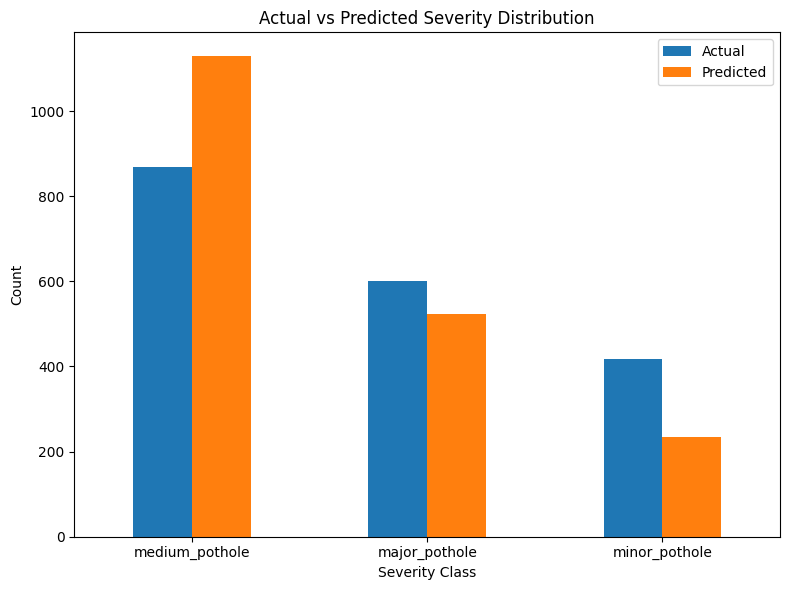

In [3]:
actual_dist = df_all['class'].value_counts()
pred_dist = df_all['predicted_severity'].value_counts()

dist_df = pd.DataFrame({'Actual': actual_dist, 'Predicted': pred_dist}).fillna(0)
print("Severity Distribution:")
print(dist_df)

dist_df.plot(kind='bar', figsize=(8, 6))
plt.title('Actual vs Predicted Severity Distribution')
plt.ylabel('Count')
plt.xlabel('Severity Class')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/severity_distribution.png')
plt.show()


# 5. Confidence Analysis

Confidence Analysis:
Mean: 0.6606
Median: 0.6639
Min: 0.4025
Max: 0.9150


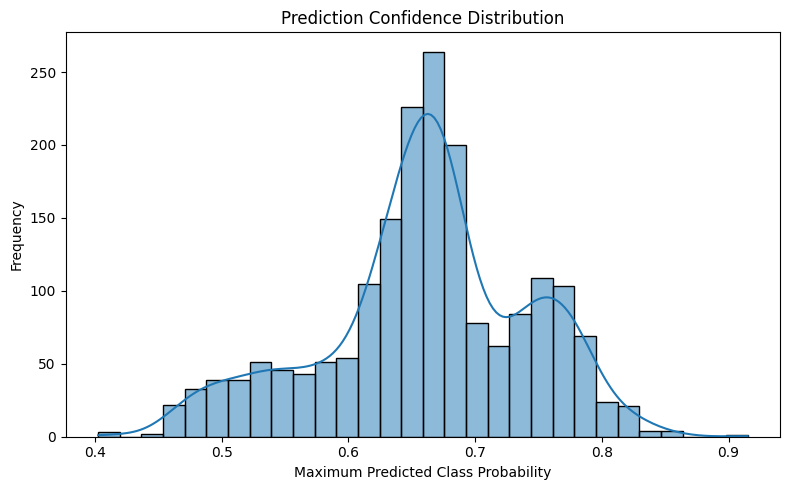

In [4]:
conf = df_all['prediction_confidence']
print("Confidence Analysis:")
print(f"Mean: {conf.mean():.4f}")
print(f"Median: {conf.median():.4f}")
print(f"Min: {conf.min():.4f}")
print(f"Max: {conf.max():.4f}")

plt.figure(figsize=(8, 5))
sns.histplot(conf, bins=30, kde=True)
plt.title('Prediction Confidence Distribution')
plt.xlabel('Maximum Predicted Class Probability')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('../outputs/figures/confidence_distribution.png')
plt.show()


# 6. Uncertainty / Ambiguity Analysis
Uncertainty is defined transparently as `1 - prediction_confidence`.

In [5]:
df_all['uncertainty'] = 1.0 - df_all['prediction_confidence']


# 7. Repair Priority Framework & Scoring
The priority score is an expected-severity calculation based strictly on model probabilities.

In [6]:
# Priority Score Design: Expected Severity Score
# 3 * prob(major) + 2 * prob(medium) + 1 * prob(minor)
df_all['priority_score'] = (
    3.0 * df_all['probability_major'] +
    2.0 * df_all['probability_medium'] +
    1.0 * df_all['probability_minor']
)

def assign_priority_category(row):
    # Review Required if confidence is extremely low (e.g. max prob < 0.45)
    if row['prediction_confidence'] < 0.45:
        return 'REVIEW REQUIRED'
    elif row['priority_score'] >= 2.5:
        return 'HIGH PRIORITY'
    elif row['priority_score'] >= 1.5:
        return 'MEDIUM PRIORITY'
    else:
        return 'LOW PRIORITY'

df_all['priority_category'] = df_all.apply(assign_priority_category, axis=1)

def assign_recommendation(cat):
    if cat == 'HIGH PRIORITY':
        return 'prioritize inspection/maintenance review'
    elif cat == 'MEDIUM PRIORITY':
        return 'schedule inspection and maintenance planning'
    elif cat == 'LOW PRIORITY':
        return 'monitor and include in routine maintenance review'
    else:
        return 'manual inspection recommended because model confidence is low'

df_all['recommendation'] = df_all['priority_category'].apply(assign_recommendation)

priority_counts = df_all['priority_category'].value_counts()
print("Priority Categories:")
print(priority_counts)

df_all.to_csv('../outputs/predictions/pothole_repair_priority.csv', index=False)


Priority Categories:
priority_category
MEDIUM PRIORITY    1245
HIGH PRIORITY       468
LOW PRIORITY        168
REVIEW REQUIRED       5
Name: count, dtype: int64


# 8. Image-Level Aggregation

In [7]:
image_summary = df_all.groupby('filename').agg(
    total_potholes=('class', 'count'),
    predicted_minor=('predicted_severity', lambda x: (x == 'minor_pothole').sum()),
    predicted_medium=('predicted_severity', lambda x: (x == 'medium_pothole').sum()),
    predicted_major=('predicted_severity', lambda x: (x == 'major_pothole').sum()),
    highest_predicted_severity=('predicted_severity', lambda x: 'major_pothole' if 'major_pothole' in x.values else ('medium_pothole' if 'medium_pothole' in x.values else 'minor_pothole')),
    highest_confidence=('prediction_confidence', 'max')
).reset_index()

image_summary.to_csv('../outputs/predictions/image_level_priority_summary.csv', index=False)
print("Image-level aggregation complete. Total images:", len(image_summary))


Image-level aggregation complete. Total images: 716


# 9. Priority Visualizations

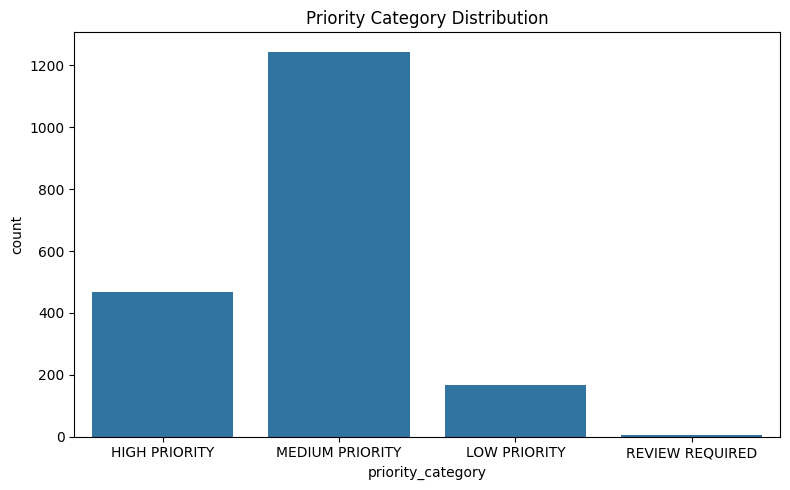

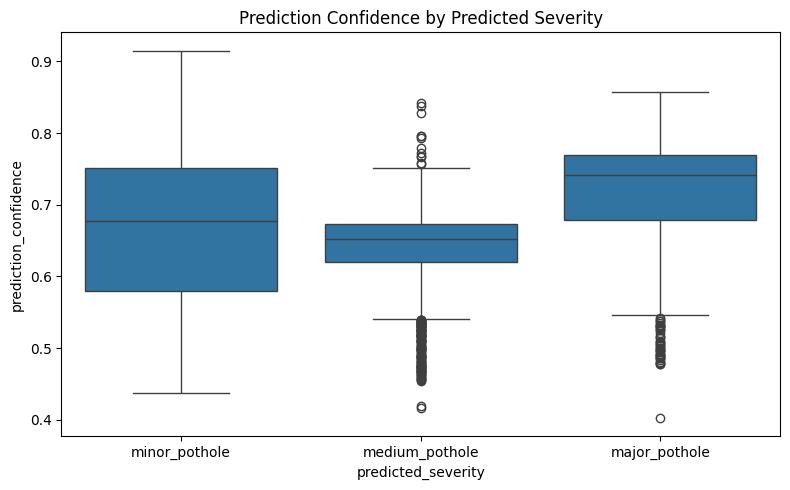

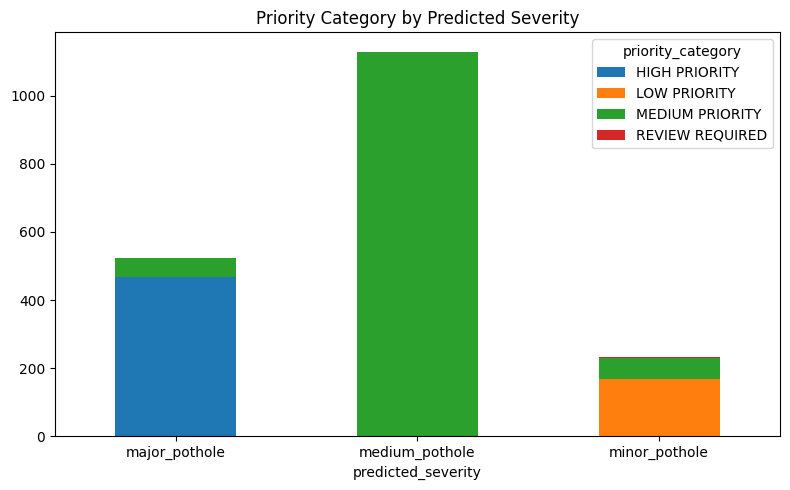

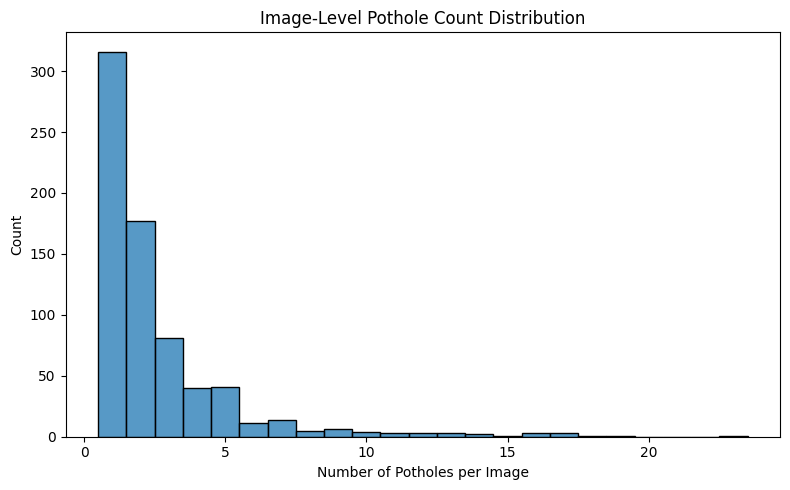

In [8]:
# 1. Priority Category Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df_all, x='priority_category', order=['HIGH PRIORITY', 'MEDIUM PRIORITY', 'LOW PRIORITY', 'REVIEW REQUIRED'])
plt.title('Priority Category Distribution')
plt.tight_layout()
plt.savefig('../outputs/figures/priority_distribution.png')
plt.show()

# 2. Severity vs Confidence
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_all, x='predicted_severity', y='prediction_confidence', order=['minor_pothole', 'medium_pothole', 'major_pothole'])
plt.title('Prediction Confidence by Predicted Severity')
plt.tight_layout()
plt.savefig('../outputs/figures/severity_vs_confidence.png')
plt.show()

# 3. Priority by Predicted Severity
cross = pd.crosstab(df_all['predicted_severity'], df_all['priority_category'])
cross.plot(kind='bar', stacked=True, figsize=(8, 5))
plt.title('Priority Category by Predicted Severity')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/priority_by_severity.png')
plt.show()

# 4. Image-level pothole count distribution
plt.figure(figsize=(8, 5))
sns.histplot(image_summary['total_potholes'], discrete=True)
plt.title('Image-Level Pothole Count Distribution')
plt.xlabel('Number of Potholes per Image')
plt.tight_layout()
plt.savefig('../outputs/figures/image_pothole_count_distribution.png')
plt.show()


# 10. Final Analytical Dataset

In [9]:
final_cols = [
    'filename', 'predicted_severity', 'probability_minor', 'probability_medium', 'probability_major',
    'prediction_confidence', 'uncertainty', 'priority_score', 'priority_category', 'recommendation',
    'bbox_width', 'bbox_height', 'bbox_area', 'rel_bbox_width', 'rel_bbox_height', 'rel_bbox_area',
    'bbox_aspect_ratio', 'log_bbox_area'
]

df_final = df_all[final_cols]
df_final.to_csv('../outputs/predictions/final_pothole_analysis.csv', index=False)
print("Final analytical dataset saved.")


Final analytical dataset saved.


# 11. Final Reports & Limitations

In [10]:
report_content = f"""# Pothole Repair Priority Report

## 1. Decision-Support Framework
The model outputs probability values for each severity class. These are transformed into an **Expected Severity Priority Score**:
`Score = (3 * probability_major) + (2 * probability_medium) + (1 * probability_minor)`

This score scales linearly from 1.0 (certain minor) to 3.0 (certain major). It balances model certainty and structural severity safely.

## 2. Priority Thresholds & Recommendations
- **HIGH PRIORITY** (Score >= 2.5): Prioritize inspection/maintenance review. (Count: {priority_counts.get('HIGH PRIORITY', 0)})
- **MEDIUM PRIORITY** (1.5 <= Score < 2.5): Schedule inspection and maintenance planning. (Count: {priority_counts.get('MEDIUM PRIORITY', 0)})
- **LOW PRIORITY** (Score < 1.5): Monitor and include in routine maintenance review. (Count: {priority_counts.get('LOW PRIORITY', 0)})
- **REVIEW REQUIRED** (Max Probability < 0.45): Manual inspection recommended because model confidence is low and ambiguous. (Count: {priority_counts.get('REVIEW REQUIRED', 0)})

## 3. Image-Level Aggregation
We successfully aggregated pothole classifications at the source image level to identify hotspots within the dataset bounds.
"""
with open('../reports/Pothole_Repair_Priority_Report.md', 'w') as f:
    f.write(report_content)

limitations_content = """# Dataset Limitations & Future Work

## 1. Current Project Limitations
1. **Dataset Nature**: The dataset is image/object-annotation based.
2. **Feature Origin**: All features are derived strictly from bounding boxes in image space, not real-world dimensions.
3. **Severity Definition**: Severity labels are manually annotated subjective categories.
4. **No Physical Measurements**: No real-world physical pothole measurements exist (e.g., depth, physical volume).
5. **No Road Condition**: No road-condition baseline variables exist.
6. **No Traffic Data**: No traffic exposure or volume metrics are available.
7. **No Geographic Tracking**: No GPS coordinates or road segment IDs exist.
8. **No Maintenance History**: No historical repair records are documented.
9. **No Cost Data**: No labor, material, or historical repair cost data exists. Thus, actual financial cost prediction is impossible.
10. **Priority Status**: The priority score is a project-defined decision-support framework derived from model probabilities, not a scientifically validated or municipal standard.

## 2. Future Work & Data Collection Recommendations
Rather than fabricating values, we strongly recommend expanding data collection integrations:
- **GPS Integration**: Tag images with precise geospatial coordinates to cluster repairs geographically.
- **Cost Data Integration**: Maintain a database of repair dimensions and corresponding financial cost to model labor/materials.
- **Traffic Modeling**: Intersect the geographic data with municipal AADT (Annual Average Daily Traffic) maps to prioritize based on user exposure.
- **Physical Sensing**: Use depth-sensing (e.g., LiDAR) to capture the Z-axis physical volume for a vastly superior structural severity assessment.
"""
with open('../reports/Dataset_Limitations_and_Future_Work.md', 'w') as f:
    f.write(limitations_content)


# 12. Final Project Summary & Audit

In [11]:
print("\n" + "="*50)
print("FINAL PROJECT SUMMARY")
print("="*50)
print(f"Dataset: 717 images, {total_potholes} cleaned pothole annotations.")
print("Classes: minor_pothole, medium_pothole, major_pothole")
print("Final model: Support Vector Machine (Tuned)")
print("Test accuracy: 65.43%")
print("Test macro F1: 65.14%")
print("\nActual Priority Distribution:")
print(priority_counts)
print("\n" + "="*50)
print("FINAL PROJECT AUDIT")
print("="*50)
print("[PASS] Part 1 completed")
print("[PASS] Part 2 completed")
print("[PASS] Part 3 completed")
print("[PASS] Part 4 completed")
print("[PASS] Part 5 completed")



FINAL PROJECT SUMMARY
Dataset: 717 images, 1886 cleaned pothole annotations.
Classes: minor_pothole, medium_pothole, major_pothole
Final model: Support Vector Machine (Tuned)
Test accuracy: 65.43%
Test macro F1: 65.14%

Actual Priority Distribution:
priority_category
MEDIUM PRIORITY    1245
HIGH PRIORITY       468
LOW PRIORITY        168
REVIEW REQUIRED       5
Name: count, dtype: int64

FINAL PROJECT AUDIT
[PASS] Part 1 completed
[PASS] Part 2 completed
[PASS] Part 3 completed
[PASS] Part 4 completed
[PASS] Part 5 completed
